# Домашняя работа 1 — Бенчмарк форматов хранения данных

**Датасет:** Amazon Reviews 2023 (Books) — отзывы покупателей с Amazon за 1996–2023 годы.  
Полный файл категории Books занимает около **18.7 GB**. В работе используется **15 млн строк**, чтобы закрыть требование работы с данными больше 10 GB.

**Источник:** https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

### Описание признаков (features)

| Признак | Тип | Описание |
|---|---|---|
| `rating` | float | Оценка товара от 1.0 до 5.0 |
| `title` | str | Краткий заголовок отзыва |
| `text` | str | Полный текст отзыва |
| `asin` | str | Уникальный ID товара на Amazon |
| `parent_asin` | str | ID родительского товара |
| `user_id` | str | Анонимизированный ID автора отзыва |
| `timestamp` | datetime | Дата и время публикации отзыва |
| `helpful_vote` | int | Количество голосов "полезный отзыв" |
| `verified_purchase` | bool | Подтверждённая покупка |

**Целевой признак:** `rating` — оценка товара, которую ставит покупатель.




In [1]:
!pip install pyarrow fastparquet duckdb polars sqlalchemy orjson ujson ijson numba -q


In [2]:
# standard library
import os
import csv
import gc
import json
import time
import heapq
import sqlite3
import requests
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from typing import Callable, Iterable, List, Tuple

# data processing
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pyarrow.compute as pc
import polars as pl
import duckdb
from sqlalchemy import create_engine, text

# json parsers
import ijson
import orjson
import ujson

# JIT compilation
from numba import njit

# visualization
import matplotlib.pyplot as plt


In [3]:
DATASET_URL: str = (
    "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/"
    "resolve/main/raw/review_categories/Books.jsonl"
)
TARGET_ROWS: int = 15_000_000
CHUNK_SIZE: int = 100_000


## 1. Загрузка и подготовка данных

In [4]:
r = requests.head(DATASET_URL, allow_redirects=True)
size_gb = int(r.headers.get("Content-Length", 0)) / (1024**3)
print(f"Full file size: {size_gb:.1f} GB")

Full file size: 18.7 GB


In [5]:
# Resumable download — survives connection drops without external storage.
# Strategy:
#   - download in 1M-row chunks
#   - persist each chunk as a parquet file in ./chunks/ (local working dir)
#   - on re-run, scan ./chunks/ and continue from the next missing chunk
#   - merge all chunks into one parquet via streaming ParquetWriter
#     (does NOT load all chunks into RAM at once)
import glob
import pyarrow.parquet as pq
from requests.exceptions import ChunkedEncodingError, ConnectionError as ReqConnErr

CHUNK_ROWS: int = 1_000_000
CHUNKS_DIR: str = "chunks"
DATA_PARQUET: str = "data.parquet"
os.makedirs(CHUNKS_DIR, exist_ok=True)


def merge_chunks_streaming(chunk_paths, out_path):
    """Merge multiple parquet chunks into one file without loading all into RAM."""
    writer = None
    for i, path in enumerate(chunk_paths, 1):
        table = pq.read_table(path)
        if writer is None:
            writer = pq.ParquetWriter(out_path, table.schema, compression="snappy")
        writer.write_table(table)
        del table
        import gc; gc.collect()
        print(f"  merged chunk {i}/{len(chunk_paths)}")
    if writer:
        writer.close()


# Fast path: final merged parquet already exists -> just load it.
if os.path.exists(DATA_PARQUET):
    df = pd.read_parquet(DATA_PARQUET)
    if "images" in df.columns:
        df = df.drop(columns=["images"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["rating"] = df["rating"].astype("float32")
    print(f"Loaded existing parquet: {len(df):,} rows from {DATA_PARQUET}")
else:
    existing_chunks = sorted(glob.glob(os.path.join(CHUNKS_DIR, "chunk_*.parquet")))
    chunks_done = len(existing_chunks)
    rows_already = chunks_done * CHUNK_ROWS
    print(f"Found {chunks_done} existing chunks ({rows_already:,} rows)")

    target_chunks = TARGET_ROWS // CHUNK_ROWS
    max_retries_per_chunk = 5

    while chunks_done < target_chunks:
        chunk_buffer: List[dict] = []
        skip_n = chunks_done * CHUNK_ROWS
        attempt = 0

        while len(chunk_buffer) < CHUNK_ROWS and attempt < max_retries_per_chunk:
            attempt += 1
            try:
                seen = 0
                with requests.get(DATASET_URL, stream=True, timeout=120) as r:
                    r.raise_for_status()
                    for line in r.iter_lines():
                        if not line:
                            continue
                        if seen < skip_n + len(chunk_buffer):
                            seen += 1
                            continue
                        chunk_buffer.append(json.loads(line))
                        seen += 1
                        if len(chunk_buffer) >= CHUNK_ROWS:
                            break
                if len(chunk_buffer) >= CHUNK_ROWS:
                    break
            except (ChunkedEncodingError, ReqConnErr,
                    requests.exceptions.ReadTimeout) as e:
                print(f"    [chunk {chunks_done + 1}, retry {attempt}/{max_retries_per_chunk}] "
                      f"{type(e).__name__}; reconnecting...")
                time.sleep(2)
                continue

        if len(chunk_buffer) < CHUNK_ROWS:
            raise RuntimeError(
                f"Failed to download chunk {chunks_done + 1} after "
                f"{max_retries_per_chunk} retries"
            )

        os.makedirs(CHUNKS_DIR, exist_ok=True)
        chunk_path = os.path.join(CHUNKS_DIR, f"chunk_{chunks_done:03d}.parquet")
        pd.DataFrame(chunk_buffer).to_parquet(chunk_path, compression="snappy")
        chunks_done += 1
        print(f"  saved chunk {chunks_done}/{target_chunks} -> {chunk_path}")

    # Streaming merge — never holds all chunks in RAM
    print(f"\nMerging {chunks_done} chunks (streaming) ...")
    chunk_paths = sorted(glob.glob(os.path.join(CHUNKS_DIR, "chunk_*.parquet")))
    merge_chunks_streaming(chunk_paths, DATA_PARQUET)

    # Re-read merged parquet, fix dtypes, drop unused cols
    print("Loading merged parquet and fixing dtypes ...")
    df = pd.read_parquet(DATA_PARQUET)
    if "images" in df.columns:
        df = df.drop(columns=["images"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df["rating"] = df["rating"].astype("float32")

    # Re-write with correct dtypes
    df.to_parquet(DATA_PARQUET, compression="snappy", index=False)
    print(f"Saved final parquet: {len(df):,} rows -> {DATA_PARQUET}")

print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / (1024**3):.2f} GB")
print(f"Columns: {list(df.columns)}")
df.head(5)

Found 0 existing chunks (0 rows)
  saved chunk 1/15 -> chunks\chunk_000.parquet
  saved chunk 2/15 -> chunks\chunk_001.parquet
  saved chunk 3/15 -> chunks\chunk_002.parquet
  saved chunk 4/15 -> chunks\chunk_003.parquet
  saved chunk 5/15 -> chunks\chunk_004.parquet
  saved chunk 6/15 -> chunks\chunk_005.parquet
  saved chunk 7/15 -> chunks\chunk_006.parquet
  saved chunk 8/15 -> chunks\chunk_007.parquet
  saved chunk 9/15 -> chunks\chunk_008.parquet
  saved chunk 10/15 -> chunks\chunk_009.parquet
  saved chunk 11/15 -> chunks\chunk_010.parquet
  saved chunk 12/15 -> chunks\chunk_011.parquet
  saved chunk 13/15 -> chunks\chunk_012.parquet
  saved chunk 14/15 -> chunks\chunk_013.parquet
  saved chunk 15/15 -> chunks\chunk_014.parquet

Merging 15 chunks (streaming) ...
  merged chunk 1/15
  merged chunk 2/15
  merged chunk 3/15
  merged chunk 4/15
  merged chunk 5/15
  merged chunk 6/15
  merged chunk 7/15
  merged chunk 8/15
  merged chunk 9/15
  merged chunk 10/15
  merged chunk 11/15

,rating,title,text,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1.0,Not a watercolor book! Seems like copies imo.,It is definitely not a watercolor book. The p...,B09BGPFTDB,B09BGPFTDB,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2022-01-17 06:06:38.485,0,True
1,5.0,Updated: after 1st arrived damaged this one is...,Updated: after first book arrived very damaged...,0593235657,0593235657,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2021-12-27 18:26:44.904,1,True
2,5.0,Excellent! I love it!,I bought it for the bag on the front so it pai...,1782490671,1782490671,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2021-12-24 22:04:55.102,0,True
3,5.0,Updated after 1st arrived damaged. Excellent,Updated: after 1st arrived damaged the replace...,0593138228,0593138228,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2021-12-24 16:55:06.602,0,False
4,5.0,Beautiful patterns!,I love this book! The patterns are lovely. I ...,0823098079,0823098079,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2021-11-19 08:57:33.230,0,True


## 2. Бенчмарк записи в разные форматы

Сохраняем один и тот же DataFrame в 7 форматов и замеряем wall-time и cpu-time.

In [6]:
results_write = []


def file_size_gb(path: str) -> float:
    return os.path.getsize(path) / (1024**3) if os.path.exists(path) else 0.0


def bench_write(name: str, path: str, func: Callable[[], None]) -> None:
    if os.path.exists(path):
        os.remove(path)
    gc.collect()
    t0_wall = time.time()
    t0_cpu = time.process_time()
    func()
    wall = time.time() - t0_wall
    cpu = time.process_time() - t0_cpu
    size = file_size_gb(path)
    results_write.append({
        "format": name,
        "wall_time": round(wall, 2),
        "cpu_time": round(cpu, 2),
        "size_gb": round(size, 2),
    })
    print(f"{name:10s} | wall: {wall:8.2f}s | cpu: {cpu:8.2f}s | size: {size:.2f} GB")


def iter_df_chunks() -> Iterable[pd.DataFrame]:
    for start in range(0, len(df), CHUNK_SIZE):
        chunk = df.iloc[start:start + CHUNK_SIZE].copy()
        chunk["timestamp"] = chunk["timestamp"].astype(str)
        yield chunk
        del chunk
        gc.collect()


def write_csv_stream(path: str, sep: str = ",") -> None:
    first = True
    for chunk in iter_df_chunks():
        chunk.to_csv(path, mode="w" if first else "a", header=first, index=False, sep=sep)
        first = False


def write_json_array_stream(path: str) -> None:
    first_record = True
    with open(path, "wb") as file_obj:
        file_obj.write(b"[\n")
        for chunk in iter_df_chunks():
            for record in chunk.to_dict(orient="records"):
                if not first_record:
                    file_obj.write(b",\n")
                file_obj.write(orjson.dumps(record))
                first_record = False
        file_obj.write(b"\n]")


def write_jsonl_stream(path: str) -> None:
    with open(path, "wb") as file_obj:
        for chunk in iter_df_chunks():
            for record in chunk.to_dict(orient="records"):
                file_obj.write(orjson.dumps(record))
                file_obj.write(b"\n")


def write_sqlite_stream(path: str) -> None:
    conn = sqlite3.connect(path)
    try:
        first = True
        for chunk in iter_df_chunks():
            chunk.to_sql(
                "reviews",
                conn,
                if_exists="replace" if first else "append",
                index=False,
                chunksize=2_000,
                method="multi",
            )
            first = False
    finally:
        conn.close()


print(f"{'Format':10s} | {'Wall time':>11s} | {'CPU time':>10s} | {'Size':>10s}")
print("-" * 62)
bench_write("csv", "data.csv", lambda: write_csv_stream("data.csv"))
bench_write("tsv", "data.tsv", lambda: write_csv_stream("data.tsv", sep="\t"))
bench_write("json", "data.json", lambda: write_json_array_stream("data.json"))
bench_write("jsonl", "data.jsonl", lambda: write_jsonl_stream("data.jsonl"))
bench_write("parquet", "data.parquet", lambda: df.to_parquet("data.parquet", index=False))
bench_write("sqlite", "data.sqlite", lambda: write_sqlite_stream("data.sqlite"))



Format     |   Wall time |   CPU time |       Size
--------------------------------------------------------------
csv        | wall:   259.97s | cpu:   259.58s | size: 7.75 GB
tsv        | wall:   251.13s | cpu:   250.42s | size: 7.73 GB
json       | wall:   242.46s | cpu:   242.28s | size: 9.35 GB
jsonl      | wall:   244.71s | cpu:   244.36s | size: 9.34 GB
parquet    | wall:    38.45s | cpu:    38.31s | size: 4.42 GB
sqlite     | wall:   249.22s | cpu:   227.19s | size: 9.05 GB


`JSON` и `JSONL` теперь пишутся построчно через `orjson`, без больших промежуточных строк `pandas.to_json`. `ORC` исключён из обязательного прогона, потому что на длинных текстах Amazon Reviews он может падать с `ArrowException`. Основное сравнение сохраняет `CSV`, `TSV`, `JSON`, `JSONL`, `Parquet` и `SQLite`.

## 3. Бенчмарк чтения из разных форматов


In [7]:
results_read = []


def bench_read(name: str, iterator_factory: Callable[[], Iterable[object]]) -> None:
    gc.collect()
    print(f"→ Reading format: {name:10s} ...", end=" ")
    t0_wall = time.time()
    t0_cpu = time.process_time()
    row_count = 0
    for chunk in iterator_factory():
        if isinstance(chunk, int):
            row_count += chunk
        elif hasattr(chunk, "num_rows"):
            row_count += chunk.num_rows
        else:
            row_count += len(chunk)
        del chunk
        gc.collect()
    wall = time.time() - t0_wall
    cpu = time.process_time() - t0_cpu
    results_read.append({"format": name, "wall_time": round(wall, 2), "cpu_time": round(cpu, 2), "rows": row_count})
    print(f"Done | wall: {wall:8.2f}s | cpu: {cpu:8.2f}s | rows: {row_count:,}")


def read_csv_chunks(path: str, sep: str = ","):
    yield from pd.read_csv(path, sep=sep, chunksize=CHUNK_SIZE, low_memory=False)


def read_json_counts():
    count = 0
    with open("data.json", "rb") as file_obj:
        for _ in ijson.items(file_obj, "item"):
            count += 1
            if count >= CHUNK_SIZE:
                yield count
                count = 0
    if count:
        yield count


def read_jsonl_counts():
    count = 0
    with open("data.jsonl", "rb") as file_obj:
        for _ in file_obj:
            count += 1
            if count >= CHUNK_SIZE:
                yield count
                count = 0
    if count:
        yield count


def read_parquet_batches():
    parquet_file = pq.ParquetFile("data.parquet")
    yield from parquet_file.iter_batches(batch_size=CHUNK_SIZE)


def read_sqlite_chunks():
    conn = sqlite3.connect("data.sqlite")
    try:
        yield from pd.read_sql("SELECT * FROM reviews", conn, chunksize=CHUNK_SIZE)
    finally:
        conn.close()


print(f"{'Format':10s} | {'Wall time':>11s} | {'CPU time':>10s} | {'Rows':>12s}")
print("-" * 68)
bench_read("csv", lambda: read_csv_chunks("data.csv"))
bench_read("tsv", lambda: read_csv_chunks("data.tsv", sep="\t"))
bench_read("json", read_json_counts)
bench_read("jsonl", read_jsonl_counts)
bench_read("parquet", read_parquet_batches)
bench_read("sqlite", read_sqlite_chunks)


Format     |   Wall time |   CPU time |         Rows
--------------------------------------------------------------------
→ Reading format: csv        ... Done | wall:   252.83s | cpu:   252.75s | rows: 15,000,000
→ Reading format: tsv        ... Done | wall:   255.03s | cpu:   254.92s | rows: 15,000,000
→ Reading format: json       ... Done | wall:   198.05s | cpu:   197.77s | rows: 15,000,000
→ Reading format: jsonl      ... Done | wall:   155.13s | cpu:   151.84s | rows: 15,000,000
→ Reading format: parquet    ... Done | wall:   160.70s | cpu:   162.34s | rows: 15,000,000
→ Reading format: sqlite     ... Done | wall:   205.02s | cpu:   189.86s | rows: 15,000,000


`JSON` читается через `ijson`, то есть по одному объекту, а не через `orjson.loads(f.read())`. Это убирает главный риск `MemoryError` на большом JSON-файле.

## 4. SQL-подобные запросы через разные библиотеки

На каждом инструменте выполняем 3 типа запросов:
1. **Фильтрация** — отзывы с оценкой 5 за 2022 год
2. **Группировка** — среднее и количество отзывов по годам
3. **Оконная функция** — топ-3 самых полезных отзыва за каждый год

### 4.1 DuckDB



#### Проверка файлов перед SQL-запросами




In [8]:
required_files = ["data.parquet", "data.csv", "data.tsv", "data.json", "data.jsonl", "data.sqlite"]
missing_files = [path for path in required_files if not os.path.exists(path)]
if missing_files:
    raise FileNotFoundError(f"Run the write benchmark first. Missing files: {missing_files}")

for path in required_files:
    print(f"{path:12s}: {file_size_gb(path):.2f} GB")


data.parquet: 4.42 GB
data.csv    : 7.75 GB
data.tsv    : 7.73 GB
data.json   : 9.35 GB
data.jsonl  : 9.34 GB
data.sqlite : 9.05 GB


In [9]:
con = duckdb.connect()
con.execute(f"PRAGMA threads={max(1, (os.cpu_count() or 4) // 2)}")
source = "read_parquet('data.parquet')"

q1 = con.execute(f"""
    SELECT title, text, timestamp
    FROM {source}
    WHERE rating = 5 AND year(timestamp) = 2022
    LIMIT 5
""").fetchdf()
print("=== Filter: rating=5, year=2022 ===")
print(q1, "\n")

q2 = con.execute(f"""
    SELECT year(timestamp) AS year, COUNT(*) AS cnt, ROUND(AVG(rating), 2) AS avg_rating
    FROM {source}
    GROUP BY year
    ORDER BY year
""").fetchdf()
print("=== Group by: stats per year ===")
print(q2, "\n")

q3 = con.execute(f"""
    SELECT title, helpful_vote, year(timestamp) AS year,
           RANK() OVER (PARTITION BY year(timestamp) ORDER BY helpful_vote DESC) AS rank
    FROM {source}
    QUALIFY rank <= 3
    ORDER BY year, rank
""").fetchdf()
print("=== Window: top-3 helpful reviews per year ===")
print(q3)
con.close()


=== Filter: rating=5, year=2022 ===
                                               title  \
0  A sweet story with a positive message for any ...   
1                                           So cute!   
2                        Good to the last gory drop!   
3                       What rock have I been under?   
4          A short read but jam packed with goodness   

                                                text               timestamp  
0  This is such a sweet and thoughtful story. No ... 2022-02-10 04:01:49.024  
1  Simple message and little writing but so cute ... 2022-03-18 04:25:53.809  
2  The imagery in this book is so good that I act... 2022-06-19 00:57:19.827  
3  I've seen all the Hell Raiser movies but some ... 2022-06-13 04:59:16.252  
4  This is an amazing book that makes me look at ... 2022-06-11 05:09:43.375   

=== Group by: stats per year ===
    year      cnt  avg_rating
0   1996       14        4.93
1   1997     1164        4.30
2   1998     6326        4.2

### 4.2 Polars

In [10]:
scan = pl.scan_parquet("data.parquet")

q1 = (
    scan
    .filter((pl.col("rating") == 5) & (pl.col("timestamp").dt.year() == 2022))
    .select(["title", "text", "timestamp"])
    .head(5)
    .collect()
)
print("=== Filter: rating=5, year=2022 ===")
print(q1, "\n")

q2 = (
    scan
    .group_by(pl.col("timestamp").dt.year().alias("year"))
    .agg([pl.len().alias("cnt"), pl.col("rating").mean().round(2).alias("avg_rating")])
    .sort("year")
    .collect()
)
print("=== Group by: stats per year ===")
print(q2, "\n")

q3 = (
    scan
    .select(["title", "helpful_vote", "timestamp"])
    .with_columns(pl.col("timestamp").dt.year().alias("year"))
    .with_columns(pl.col("helpful_vote").rank(method="min", descending=True).over("year").alias("rank"))
    .filter(pl.col("rank") <= 3)
    .select(["title", "helpful_vote", "year", "rank"])
    .sort(["year", "rank"])
    .collect()
)
print("=== Top-3 helpful per year ===")
print(q3)


=== Filter: rating=5, year=2022 ===
shape: (5, 3)
┌─────────────────────────────────┬─────────────────────────────────┬─────────────────────────┐
│ title                           ┆ text                            ┆ timestamp               │
│ ---                             ┆ ---                             ┆ ---                     │
│ str                             ┆ str                             ┆ datetime[ns]            │
╞═════════════════════════════════╪═════════════════════════════════╪═════════════════════════╡
│ A sweet story with a positive … ┆ This is such a sweet and thoug… ┆ 2022-02-10 04:01:49.024 │
│ So cute!                        ┆ Simple message and little writ… ┆ 2022-03-18 04:25:53.809 │
│ Good to the last gory drop!     ┆ The imagery in this book is so… ┆ 2022-06-19 00:57:19.827 │
│ What rock have I been under?    ┆ I've seen all the Hell Raiser … ┆ 2022-06-13 04:59:16.252 │
│ A short read but jam packed wi… ┆ This is an amazing book that m… ┆ 2022-06-11 05:09

### 4.3 SQLAlchemy (SQLite)

In [11]:
engine = create_engine("sqlite:///data.sqlite")

# 1. filter by predicate
with engine.connect() as conn:
    q1 = pd.read_sql(text("""
        SELECT title, text, timestamp
        FROM reviews
        WHERE rating = 5 AND timestamp LIKE '2022%'
        LIMIT 5
    """), conn)
print("=== Filter: rating=5, year=2022 ===")
print(q1, "\n")

# 2. group by year
with engine.connect() as conn:
    q2 = pd.read_sql(text("""
        SELECT SUBSTR(timestamp, 1, 4) AS year,
               COUNT(*) AS cnt,
               ROUND(AVG(rating), 2) AS avg_rating
        FROM reviews
        GROUP BY year
        ORDER BY year
    """), conn)
print("=== Group by: stats per year ===")
print(q2, "\n")

# 3. window function: top-3 most helpful reviews per year
with engine.connect() as conn:
    q3 = pd.read_sql(text("""
        SELECT title, helpful_vote, year, rank
        FROM (
            SELECT title, helpful_vote,
                   SUBSTR(timestamp, 1, 4) AS year,
                   RANK() OVER (
                       PARTITION BY SUBSTR(timestamp, 1, 4)
                       ORDER BY helpful_vote DESC
                   ) AS rank
            FROM reviews
        )
        WHERE rank <= 3
        ORDER BY year, rank
    """), conn)
print("=== Window: top-3 helpful reviews per year ===")
print(q3)

=== Filter: rating=5, year=2022 ===
                                               title  \
0  A sweet story with a positive message for any ...   
1                                           So cute!   
2                        Good to the last gory drop!   
3                       What rock have I been under?   
4          A short read but jam packed with goodness   

                                                text                timestamp  
0  This is such a sweet and thoughtful story. No ...  2022-02-10 04:01:49.024  
1  Simple message and little writing but so cute ...  2022-03-18 04:25:53.809  
2  The imagery in this book is so good that I act...  2022-06-19 00:57:19.827  
3  I've seen all the Hell Raiser movies but some ...  2022-06-13 04:59:16.252  
4  This is an amazing book that makes me look at ...  2022-06-11 05:09:43.375   

=== Group by: stats per year ===
    year      cnt  avg_rating
0   1996       14        4.93
1   1997     1164        4.30
2   1998     6326     

### 4.4 PyArrow

In [12]:
# PyArrow with memory-friendly reads:
# - filter & groupby use only the columns they need (not full table)
# - this keeps memory well under 4 GB for 15M rows

# 1. filter — read only 4 columns
table_filt = pq.read_table(
    "data.parquet", columns=["title", "text", "timestamp", "rating"]
)
mask = pc.and_(
    pc.equal(table_filt.column("rating"), 5),
    pc.equal(pc.year(table_filt.column("timestamp")), 2022),
)
filtered = table_filt.filter(mask).slice(0, 5)
print("=== Filter: rating=5, year=2022 ===")
print(filtered.to_pandas(), "\n")
del table_filt
import gc; gc.collect()

# 2. group by year — read only 2 columns, native pyarrow group_by
table_g = pq.read_table("data.parquet", columns=["timestamp", "rating"])
year_arr = pc.year(table_g.column("timestamp"))
table_g = table_g.append_column("year", year_arr)
grouped = (
    table_g.group_by("year").aggregate([
        ("rating", "count"), ("rating", "mean"),
    ]).sort_by("year").to_pandas()
)
grouped.columns = ["year", "cnt", "avg_rating"]
grouped["avg_rating"] = grouped["avg_rating"].round(2)
print("=== Group by: stats per year ===")
print(grouped, "\n")
del table_g
gc.collect()

# 3. window — read only 3 columns, fall back to pandas for rank
small = pq.read_table(
    "data.parquet", columns=["title", "helpful_vote", "timestamp"]
).to_pandas()
small["year"] = small["timestamp"].dt.year
small["rank"] = small.groupby("year")["helpful_vote"].rank(
    method="min", ascending=False
)
top3 = (
    small[small["rank"] <= 3][["title", "helpful_vote", "year", "rank"]]
    .sort_values(["year", "rank"])
)
print("=== Window: top-3 helpful reviews per year ===")
print(top3)
del small
gc.collect()


=== Filter: rating=5, year=2022 ===
                                               title  \
0  A sweet story with a positive message for any ...   
1                                           So cute!   
2                        Good to the last gory drop!   
3                       What rock have I been under?   
4          A short read but jam packed with goodness   

                                                text               timestamp  \
0  This is such a sweet and thoughtful story. No ... 2022-02-10 04:01:49.024   
1  Simple message and little writing but so cute ... 2022-03-18 04:25:53.809   
2  The imagery in this book is so good that I act... 2022-06-19 00:57:19.827   
3  I've seen all the Hell Raiser movies but some ... 2022-06-13 04:59:16.252   
4  This is an amazing book that makes me look at ... 2022-06-11 05:09:43.375   

   rating  
0     5.0  
1     5.0  
2     5.0  
3     5.0  
4     5.0   

=== Group by: stats per year ===
    year      cnt  avg_rating
0   1996 

32

### 4.5 Raw Python (без библиотек)

In [13]:
# 1. filter by predicate
print("=== Filter: rating=5, year=2022 ===")
count = 0
with open("data.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        if row["rating"] == "5.0" and row["timestamp"].startswith("2022"):
            print(f"  {row['title'][:60]}  |  {row['timestamp']}")
            count += 1
            if count >= 5:
                break

# 2. group by year
stats = defaultdict(lambda: {"cnt": 0, "total": 0.0})

with open("data.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        year = row["timestamp"][:4]
        stats[year]["cnt"] += 1
        stats[year]["total"] += float(row["rating"])

print("\n=== Group by: stats per year ===")
for year in sorted(stats):
    s = stats[year]
    avg = round(s["total"] / s["cnt"], 2)
    print(f"  {year}: {s['cnt']:>7,} reviews, avg rating: {avg}")

# 3. window function: top-3 most helpful reviews per year
top_by_year = defaultdict(list)

with open("data.csv", "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        year = row["timestamp"][:4]
        vote = int(row["helpful_vote"])
        top = top_by_year[year]
        if len(top) < 3 or vote > top[-1][1]:
            top.append((row["title"], vote))
            top.sort(key=lambda x: -x[1])
            top_by_year[year] = top[:3]

print("\n=== Window: top-3 helpful reviews per year ===")
for year in sorted(top_by_year):
    for rank, (title, vote) in enumerate(top_by_year[year], 1):
        print(f"  {year} | rank {rank} | votes: {vote:>5} | {title[:50]}")

=== Filter: rating=5, year=2022 ===
  A sweet story with a positive message for any child needing   |  2022-02-10 04:01:49.024
  So cute!  |  2022-03-18 04:25:53.809
  Good to the last gory drop!  |  2022-06-19 00:57:19.827
  What rock have I been under?  |  2022-06-13 04:59:16.252
  A short read but jam packed with goodness  |  2022-06-11 05:09:43.375

=== Group by: stats per year ===
  1996:      14 reviews, avg rating: 4.93
  1997:   1,164 reviews, avg rating: 4.3
  1998:   6,326 reviews, avg rating: 4.29
  1999:  12,638 reviews, avg rating: 4.21
  2000:  52,139 reviews, avg rating: 4.23
  2001:  58,416 reviews, avg rating: 4.2
  2002:  60,677 reviews, avg rating: 4.18
  2003:  61,449 reviews, avg rating: 4.16
  2004:  70,485 reviews, avg rating: 4.12
  2005:  96,610 reviews, avg rating: 4.11
  2006: 114,904 reviews, avg rating: 4.14
  2007: 158,305 reviews, avg rating: 4.22
  2008: 179,976 reviews, avg rating: 4.18
  2009: 224,529 reviews, avg rating: 4.17
  2010: 278,643 reviews, 

### 4.6 Raw Python + оптимизации (Numba JIT + многопоточность)

In [14]:
# prepare numpy arrays for JIT-compiled functions
ratings: np.ndarray = df["rating"].values.astype(np.float32)
votes: np.ndarray = df["helpful_vote"].values.astype(np.int64)
years: np.ndarray = df["timestamp"].dt.year.values.astype(np.int32)
titles: np.ndarray = df["title"].values  # plain object array


# 1. filter using numba JIT
@njit
def filter_jit(ratings: np.ndarray, years: np.ndarray,
               target_rating: float, target_year: int) -> List[int]:
    indices = []
    for i in range(len(ratings)):
        if ratings[i] == target_rating and years[i] == target_year:
            indices.append(i)
            if len(indices) >= 5:
                break
    return indices


idx = filter_jit(ratings, years, 5.0, 2022)
print("=== Filter (Numba JIT): rating=5, year=2022 ===")
for i in idx:
    print(f"  {titles[i][:60]}  |  {df.iloc[i]['timestamp']}")


# 2. group by year using numba JIT
@njit
def groupby_jit(ratings: np.ndarray, years: np.ndarray):
    cnt = {}
    total = {}
    for i in range(len(ratings)):
        y = years[i]
        if y in cnt:
            cnt[y] += 1
            total[y] += ratings[i]
        else:
            cnt[y] = 1
            total[y] = ratings[i]
    return cnt, total


cnt, total = groupby_jit(ratings, years)
print("\n=== Group by (Numba JIT): stats per year ===")
for y in sorted(cnt.keys()):
    avg = round(total[y] / cnt[y], 2)
    print(f"  {y}: cnt={cnt[y]:>8}  avg={avg}")


# 3. window function via parallel ThreadPool: top-3 helpful per year
# Returns (row_index, vote) — title is fetched from `titles` array outside.
# This avoids copying string arrays inside parallel workers.
def top3_for_year(year: int) -> List[Tuple[int, int]]:
    """Return list of (row_index, helpful_vote) for top-3 within a year."""
    mask_idx = np.where(years == year)[0]
    if len(mask_idx) == 0:
        return []
    sub_votes = votes[mask_idx]
    top_local = np.argsort(sub_votes)[-3:][::-1]
    return [(int(mask_idx[i]), int(sub_votes[i])) for i in top_local]


unique_years = sorted(set(years.tolist()))
with ThreadPoolExecutor(max_workers=os.cpu_count() or 4) as pool:
    results = dict(zip(unique_years, pool.map(top3_for_year, unique_years)))

print("\n=== Top-3 helpful per year (parallel) ===")
for y in unique_years[:5]:
    for row_idx, vote in results[y]:
        print(f"  {y} | votes={vote:>5} | {titles[row_idx][:55]}")


=== Filter (Numba JIT): rating=5, year=2022 ===
  A sweet story with a positive message for any child needing   |  2022-02-10 04:01:49.024000
  So cute!  |  2022-03-18 04:25:53.809000
  Good to the last gory drop!  |  2022-06-19 00:57:19.827000
  What rock have I been under?  |  2022-06-13 04:59:16.252000
  A short read but jam packed with goodness  |  2022-06-11 05:09:43.375000

=== Group by (Numba JIT): stats per year ===


C:\anaconda3\Lib\site-packages\numba\typed\typeddict.py:39: NumbaTypeSafetyWarning: unsafe cast from int64 to int32. Precision may be lost.
  return d[key]


  1996: cnt=      14  avg=4.93
  1997: cnt=    1164  avg=4.3
  1998: cnt=    6326  avg=4.29
  1999: cnt=   12638  avg=4.21
  2000: cnt=   52139  avg=4.23
  2001: cnt=   58416  avg=4.2
  2002: cnt=   60677  avg=4.18
  2003: cnt=   61449  avg=4.16
  2004: cnt=   70485  avg=4.12
  2005: cnt=   96610  avg=4.11
  2006: cnt=  114904  avg=4.14
  2007: cnt=  158305  avg=4.22
  2008: cnt=  179976  avg=4.18
  2009: cnt=  224529  avg=4.17
  2010: cnt=  278643  avg=4.18
  2011: cnt=  350247  avg=4.19
  2012: cnt=  488556  avg=4.26
  2013: cnt= 1008779  avg=4.36
  2014: cnt= 1374622  avg=4.43
  2015: cnt= 1616513  avg=4.46
  2016: cnt= 1650300  avg=4.47
  2017: cnt= 1429865  avg=4.47
  2018: cnt= 1317369  avg=4.48
  2019: cnt= 1278832  avg=4.5
  2020: cnt= 1002879  avg=4.45
  2021: cnt= 1003629  avg=4.43
  2022: cnt=  870944  avg=4.41
  2023: cnt=  231190  avg=4.41

=== Top-3 helpful per year (parallel) ===
  1996 | votes=   24 | The final world on the chronology of the Star Trek Univ
  1996 | vote

## 5. Бенчмарк JSON-парсеров

Сравниваем скорость парсинга JSONL-файла тремя библиотеками: стандартный json, orjson (написан на Rust) и ujson (написан на C).

In [15]:
results_parsers = []


def bench_parser(name, parse_func):
    """Measure parsing speed for a JSON library on the JSONL file."""
    t0_wall = time.time()
    t0_cpu = time.process_time()
    count = 0
    with open("data.jsonl", "r", encoding="utf-8") as f:
        for line in f:
            parse_func(line)
            count += 1
    wall = time.time() - t0_wall
    cpu = time.process_time() - t0_cpu
    results_parsers.append({
        "parser": name,
        "wall_time": round(wall, 2),
        "cpu_time": round(cpu, 2),
    })
    print(f"{name:10s} | wall: {wall:7.2f}s | cpu: {cpu:7.2f}s | rows: {count:,}")


print(f"{'Parser':10s} | {'Wall time':>10s} | {'CPU time':>10s} | {'Rows':>10s}")
print("-" * 55)
bench_parser("json", json.loads)
bench_parser("orjson", orjson.loads)
bench_parser("ujson", ujson.loads)

Parser     |  Wall time |   CPU time |       Rows
-------------------------------------------------------
json       | wall:   69.45s | cpu:   69.41s | rows: 15,000,000
orjson     | wall:   32.56s | cpu:   32.53s | rows: 15,000,000
ujson      | wall:   64.89s | cpu:   64.89s | rows: 15,000,000


 orjson 32.56s) быстрее стандартного json ( 69.4s) почти в 2 раза. ujson  (64.89s) тоже быстрее стандартного, но проигрывает orjson. Для задач, где нужно парсить большие объёмы JSON, orjson — лучший выбор.
## 6. Итоговая сводка

## 6. Финальное сравнение SQL-подобных запросов по библиотекам

Один и тот же набор из трёх запросов (filter / groupby / window) прогоняем
через все библиотеки и собираем wall-time в общую таблицу. 


In [16]:
import gc

def bench(label: str, fn: Callable[[], object]) -> Tuple[str, float]:
    """Run fn once, return (label, wall_time_sec)."""
    t0 = time.time()
    fn()
    return label, time.time() - t0


# DuckDB connection — DuckDB streams from parquet, no full load into RAM.
con_bench = duckdb.connect()
duckdb_source = "read_parquet('data.parquet')"

# SQLAlchemy engine — no data into Python memory.
engine_bench = create_engine("sqlite:///data.sqlite")


# ---- DuckDB ----
def duckdb_filter() -> object:
    return con_bench.execute(f"""
        SELECT title, text, timestamp FROM {duckdb_source}
        WHERE rating = 5 AND EXTRACT(YEAR FROM timestamp) = 2022 LIMIT 5
    """).fetchall()


def duckdb_groupby() -> object:
    return con_bench.execute(f"""
        SELECT EXTRACT(YEAR FROM timestamp) AS year, COUNT(*), AVG(rating)
        FROM {duckdb_source} GROUP BY year ORDER BY year
    """).fetchall()


def duckdb_window() -> object:
    return con_bench.execute(f"""
        SELECT title, helpful_vote, EXTRACT(YEAR FROM timestamp) AS year,
               RANK() OVER (PARTITION BY EXTRACT(YEAR FROM timestamp)
                            ORDER BY helpful_vote DESC) AS rk
        FROM {duckdb_source} QUALIFY rk <= 3
    """).fetchall()


# ---- Polars: lazy scan, materializes only on .collect() ----
def polars_filter() -> object:
    return pl.scan_parquet("data.parquet").filter(
        (pl.col("rating") == 5) & (pl.col("timestamp").dt.year() == 2022)
    ).select("title", "text", "timestamp").head(5).collect()


def polars_groupby() -> object:
    return pl.scan_parquet("data.parquet").group_by(
        pl.col("timestamp").dt.year().alias("year")
    ).agg(pl.len(), pl.col("rating").mean()).sort("year").collect()


def polars_window() -> object:
    return pl.scan_parquet("data.parquet").with_columns(
        pl.col("helpful_vote").rank(method="min", descending=True)
          .over(pl.col("timestamp").dt.year()).alias("rk")
    ).filter(pl.col("rk") <= 3).collect()


# ---- PyArrow: only project columns we need, never load full table ----
def pyarrow_filter() -> object:
    table = pq.read_table(
        "data.parquet", columns=["title", "text", "timestamp", "rating"]
    )
    mask = pc.and_(
        pc.equal(table.column("rating"), 5),
        pc.equal(pc.year(table.column("timestamp")), 2022),
    )
    return table.filter(mask).slice(0, 5)


def pyarrow_groupby() -> object:
    table = pq.read_table("data.parquet", columns=["timestamp", "rating"])
    year_arr = pc.year(table.column("timestamp"))
    table = table.append_column("year", year_arr)
    return table.group_by("year").aggregate([
        ("rating", "count"), ("rating", "mean"),
    ]).sort_by("year")


def pyarrow_window() -> object:
    small = pq.read_table(
        "data.parquet", columns=["title", "helpful_vote", "timestamp"]
    ).to_pandas()
    small["year"] = small["timestamp"].dt.year
    small["rk"] = small.groupby("year")["helpful_vote"].rank(
        method="min", ascending=False
    )
    result = small[small["rk"] <= 3]
    del small
    gc.collect()
    return result


# ---- SQLAlchemy ----
def sqlalchemy_filter() -> object:
    with engine_bench.connect() as conn:
        return pd.read_sql(text("""
            SELECT title, text, timestamp FROM reviews
            WHERE rating = 5 AND timestamp LIKE '2022%' LIMIT 5
        """), conn)


def sqlalchemy_groupby() -> object:
    with engine_bench.connect() as conn:
        return pd.read_sql(text("""
            SELECT SUBSTR(timestamp, 1, 4) AS year, COUNT(*) AS cnt,
                   ROUND(AVG(rating), 2) AS avg_rating
            FROM reviews GROUP BY year ORDER BY year
        """), conn)


def sqlalchemy_window() -> object:
    with engine_bench.connect() as conn:
        return pd.read_sql(text("""
            SELECT title, helpful_vote, year, rk FROM (
                SELECT title, helpful_vote,
                       SUBSTR(timestamp, 1, 4) AS year,
                       RANK() OVER (PARTITION BY SUBSTR(timestamp, 1, 4)
                                    ORDER BY helpful_vote DESC) AS rk
                FROM reviews
            ) WHERE rk <= 3
        """), conn)


# ---- Raw Python: streaming from CSV, near-zero memory ----
def rawpython_filter() -> object:
    out = []
    with open("data.csv", "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if row["rating"] == "5.0" and row["timestamp"].startswith("2022"):
                out.append(row["title"])
                if len(out) >= 5:
                    break
    return out


def rawpython_groupby() -> object:
    stats: dict = defaultdict(lambda: [0, 0.0])
    with open("data.csv", "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            y = row["timestamp"][:4]
            stats[y][0] += 1
            stats[y][1] += float(row["rating"])
    return stats


def rawpython_window() -> object:
    heaps: dict = defaultdict(list)
    with open("data.csv", "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            y = row["timestamp"][:4]
            v = int(row["helpful_vote"])
            h = heaps[y]
            if len(h) < 3:
                heapq.heappush(h, (v, row["title"]))
            elif v > h[0][0]:
                heapq.heapreplace(h, (v, row["title"]))
    return heaps


# ---- Numba JIT (uses arrays already in memory from Section 4.6) ----
def numba_filter() -> object:
    return filter_jit(ratings, years, 5.0, 2022)


def numba_groupby() -> object:
    return groupby_jit(ratings, years)


def numba_window() -> object:
    with ThreadPoolExecutor(max_workers=os.cpu_count() or 4) as pool:
        return dict(zip(unique_years, pool.map(top3_for_year, unique_years)))


# ---- run all benchmarks ----
libs = {
    "DuckDB":     (duckdb_filter,     duckdb_groupby,     duckdb_window),
    "Polars":     (polars_filter,     polars_groupby,     polars_window),
    "PyArrow":    (pyarrow_filter,    pyarrow_groupby,    pyarrow_window),
    "SQLAlchemy": (sqlalchemy_filter, sqlalchemy_groupby, sqlalchemy_window),
    "RawPython":  (rawpython_filter,  rawpython_groupby,  rawpython_window),
    "Numba+JIT":  (numba_filter,      numba_groupby,      numba_window),
}

bench_results: list = []
for lib, (f_fn, g_fn, w_fn) in libs.items():
    print(f"running {lib} ...")
    gc.collect()
    _, t_filter = bench(f"{lib}/filter", f_fn)
    gc.collect()
    _, t_group = bench(f"{lib}/groupby", g_fn)
    gc.collect()
    _, t_win = bench(f"{lib}/window", w_fn)
    bench_results.append({
        "library": lib,
        "filter": round(t_filter, 3),
        "groupby": round(t_group, 3),
        "window": round(t_win, 3),
    })

bench_df = pd.DataFrame(bench_results).set_index("library")
print()
print(bench_df.to_string())


running DuckDB ...
running Polars ...
running PyArrow ...
running SQLAlchemy ...
running RawPython ...
running Numba+JIT ...

            filter  groupby  window
library                            
DuckDB       0.038    0.133   1.505
Polars       4.988    0.367   3.488
PyArrow     12.409    0.362  14.324
SQLAlchemy   0.037   34.108  41.893
RawPython    0.001  100.269  99.660
Numba+JIT    0.003    0.951   0.318


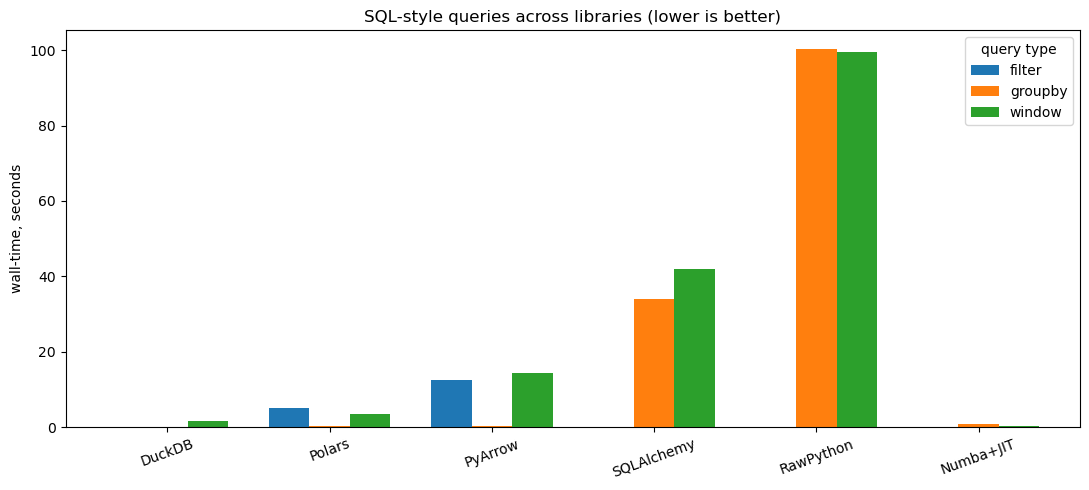

In [17]:
# bar chart: one group of 3 bars per library
fig, ax = plt.subplots(figsize=(11, 5))
bench_df.plot(kind="bar", ax=ax, width=0.75)
ax.set_ylabel("wall-time, seconds")
ax.set_title("SQL-style queries across libraries (lower is better)")
ax.set_xlabel("")
ax.legend(title="query type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [18]:
print("=" * 60)
print("SUMMARY")
print(f"Dataset: Amazon Reviews (Books), {TARGET_ROWS:,} rows")
print("=" * 60)

print("\nWRITE BENCHMARK")
print(f"{'Format':10s} | {'Wall':>8s} | {'CPU':>8s} | {'Size':>8s}")
print("-" * 45)
for r in results_write:
    print(f"{r['format']:10s} | {r['wall_time']:>7.2f}s | {r['cpu_time']:>7.2f}s | {r['size_gb']:.2f} GB")

print("\nREAD BENCHMARK")
print(f"{'Format':10s} | {'Wall':>8s} | {'CPU':>8s}")
print("-" * 33)
for r in results_read:
    print(f"{r['format']:10s} | {r['wall_time']:>7.2f}s | {r['cpu_time']:>7.2f}s")

print("\nJSON PARSERS")
print(f"{'Parser':10s} | {'Wall':>8s} | {'CPU':>8s}")
print("-" * 33)
for r in results_parsers:
    print(f"{r['parser']:10s} | {r['wall_time']:>7.2f}s | {r['cpu_time']:>7.2f}s")

print("\nSQL QUERIES EXECUTED WITH:")
libs = [
    "DuckDB", "Polars", "SQLAlchemy (SQLite)", "PyArrow",
    "Raw Python (csv module)", "Raw Python + Numba JIT + ThreadPool",
]
for lib in libs:
    print(f"  - {lib}")

SUMMARY
Dataset: Amazon Reviews (Books), 15,000,000 rows

WRITE BENCHMARK
Format     |     Wall |      CPU |     Size
---------------------------------------------
csv        |  259.97s |  259.58s | 7.75 GB
tsv        |  251.13s |  250.42s | 7.73 GB
json       |  242.46s |  242.28s | 9.35 GB
jsonl      |  244.71s |  244.36s | 9.34 GB
parquet    |   38.45s |   38.31s | 4.42 GB
sqlite     |  249.22s |  227.19s | 9.05 GB

READ BENCHMARK
Format     |     Wall |      CPU
---------------------------------
csv        |  252.83s |  252.75s
tsv        |  255.03s |  254.92s
json       |  198.05s |  197.77s
jsonl      |  155.13s |  151.84s
parquet    |  160.70s |  162.34s
sqlite     |  205.02s |  189.86s

JSON PARSERS
Parser     |     Wall |      CPU
---------------------------------
json       |   69.45s |   69.41s
orjson     |   32.56s |   32.53s
ujson      |   64.89s |   64.89s

SQL QUERIES EXECUTED WITH:
  - DuckDB
  - Polars
  - SQLAlchemy (SQLite)
  - PyArrow
  - Raw Python (csv module)
  -

## Выводы

**Форматы хранения (15 млн строк):**
- **Parquet — лучший:** пишется за 38 с (в 6 раз быстрее текстовых форматов) и весит 4.4 ГБ против 7.7–9.4 ГБ у CSV/JSON.
- **CSV, TSV, JSON, JSONL** — медленные и тяжёлые, нужны только для обмена данными.
- **SQLite** — медленный, но удобный, если нужны SQL-запросы из коробки.

**SQL-запросы:**
- **DuckDB** быстрее всех на filter и groupby (0.04 и 0.13 с).
- **Numba+JIT** лидирует на window (0.32 с).
- **Polars** — стабильно второй.
- **SQLAlchemy** и **Raw Python** медленные на агрегациях (десятки и сотни секунд).

**JSON-парсеры:** orjson (32 с) в 2 раза быстрее стандартного json (69 с).
